Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


 94%|=================== | 3865/4128 [00:12<00:00]       

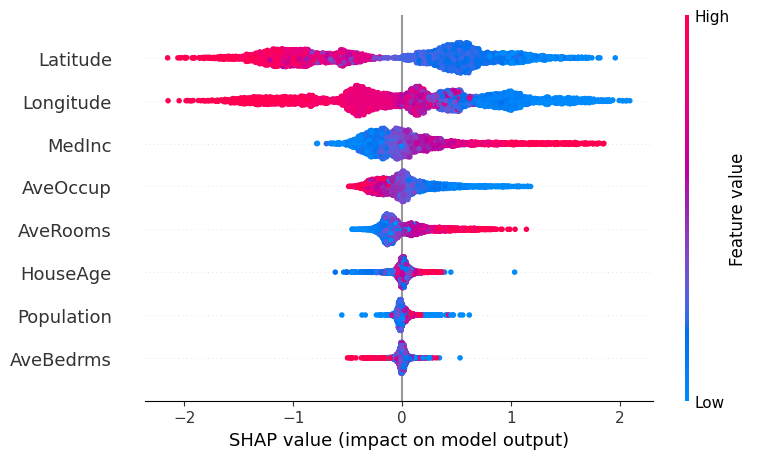

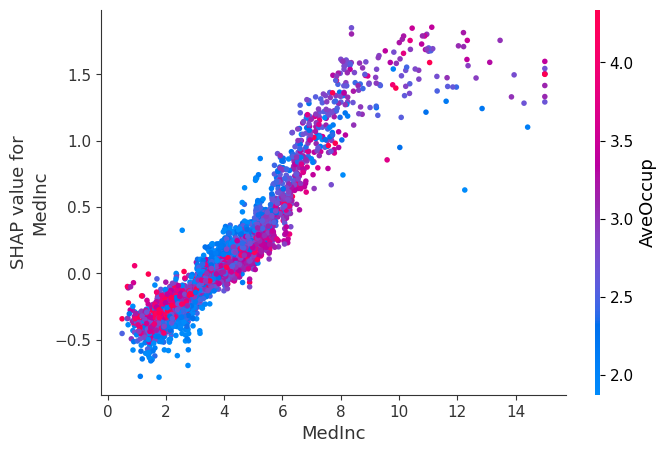

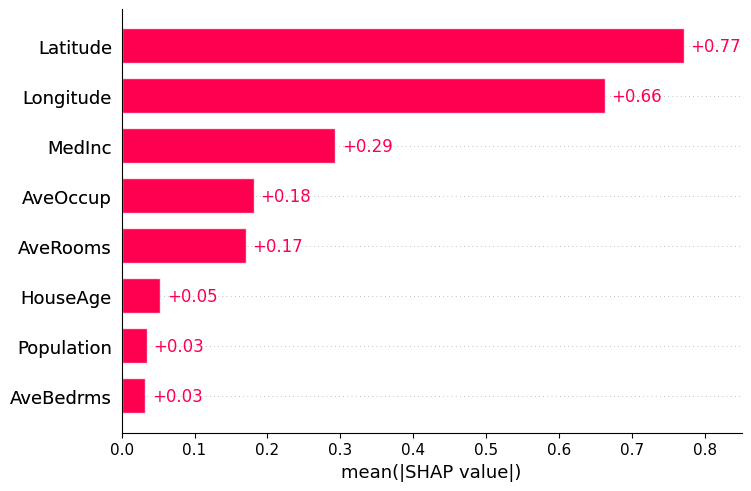

In [2]:
import shap
import xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load California housing dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(X.columns)
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgboost.XGBRegressor().fit(X_train, y_train)

# Explain model predictions using SHAP
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)

# Plot summary plot
shap.summary_plot(shap_values, X_test,feature_names=X_train.columns)
shap.dependence_plot("MedInc",shap_values.values,X_test)
shap.plots.bar(shap_values)

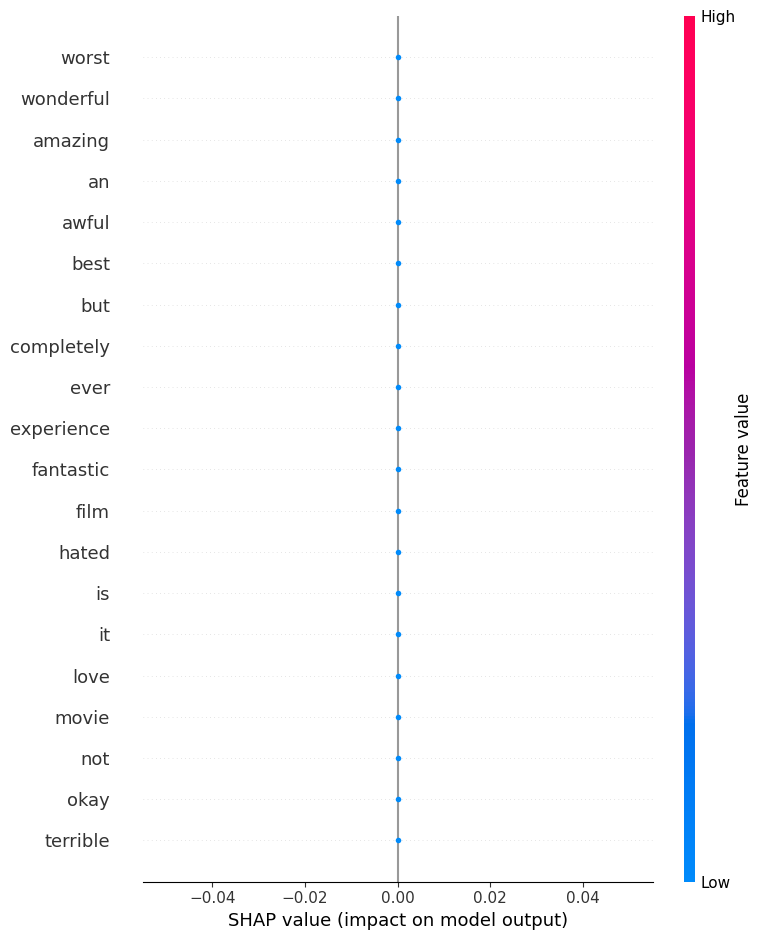

In [5]:
import shap
import xgboost
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Data
texts = [
    "I love this movie, it is fantastic!",
    "This film was terrible, I hated it.",
    "An amazing experience, absolutely wonderful.",
    "Worst movie ever, completely awful.",
    "It was okay, not the best but not the worst."
]
labels = [1, 0, 1, 0, 1]

# Vectorize
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Model
model = xgboost.XGBClassifier()
model.fit(X_train_dense, y_train)

# SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test_dense)

# Plot
shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names)


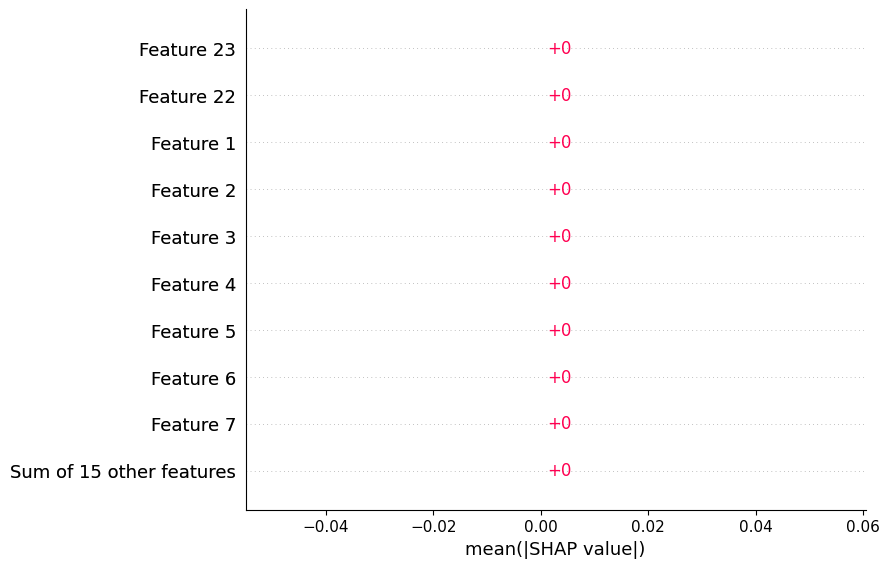

In [8]:
shap.plots.bar(shap_values, max_display=10)


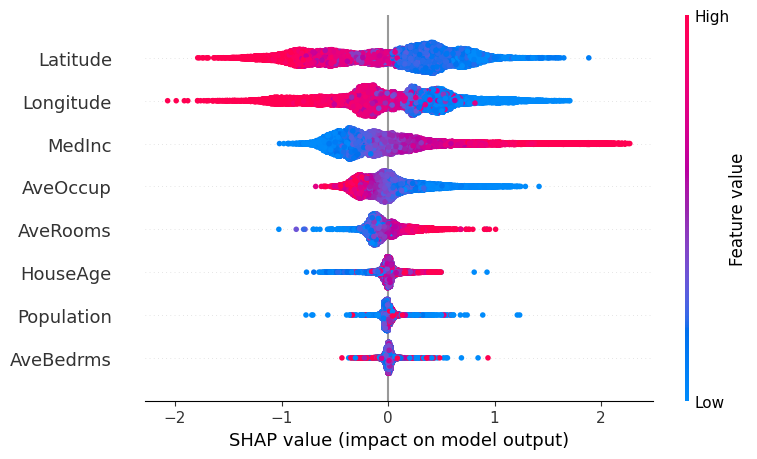

In [3]:
features = data.data
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)
shap.summary_plot(shap_values,features,feature_names=data.feature_names)

In [2]:
import shap
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load a sample dataset (for demonstration, using MNIST)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator


data_dir = "LAB/image1"
split_ratio=0.8
train_datagen = ImageDataGenerator(rescale=1/255,
                                 validation_split=1 - split_ratio)



In [3]:
train_generator = train_datagen.flow_from_directory(data_dir,
                                                    target_size=(150,150),
                                                    batch_size=32,
                                                    class_mode='binary',
                                                    subset='training')

Found 145 images belonging to 2 classes.


In [4]:
test_generator = train_datagen.flow_from_directory(data_dir,
                                                   target_size=(150,150),
                                                   batch_size=32,
                                                   class_mode='binary',
                                                   subset='training')

Found 145 images belonging to 2 classes.


In [5]:
# Normalize pixel values to 0-1
from tensorflow.keras.layers import Conv2D,MaxPool2D
# Build a simple neural network
model = Sequential([
    Conv2D(25, kernel_size=(3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (using fewer epochs for quick results)
model.fit(train_generator, steps_per_epoch=train_generator.samples,
         epochs=10,
         validation_data=test_generator,
         validation_steps=test_generator.samples)


C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
  5/145 ━━━━━━━━━━━━━━━━━━━━ 46s 334ms/step - accuracy: 0.4340 - loss: 6.8847

C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4544 - loss: 6.0330 - val_accuracy: 0.3931 - val_loss: 0.7319
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5429 - loss: 0.6932 - val_accuracy: 0.3931 - val_loss: 0.7426
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5500 - loss: 0.6915 - val_accuracy: 0.6069 - val_loss: 0.6597
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6086 - loss: 0.7287 - val_accuracy: 0.6069 - val_loss: 0.6617
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5936 - loss: 0.6684 - val_accuracy: 0.6069 - val_loss: 0.6732
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6074 - loss: 0.6896 - val_accuracy: 0.6069 - val_loss: 0.6972
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5112 - loss: 0.7056 - val_accuracy: 0.6690 - val_loss: 0.6744
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6080 - loss: 0.6707 - val_accuracy: 0.6069 - val

C:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(32, 150, 150, 3))']
  warnings.warn(msg)
C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(64, 150, 150, 3))']
  warnings.warn(msg)
C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't m

<Figure size 800x400 with 0 Axes>

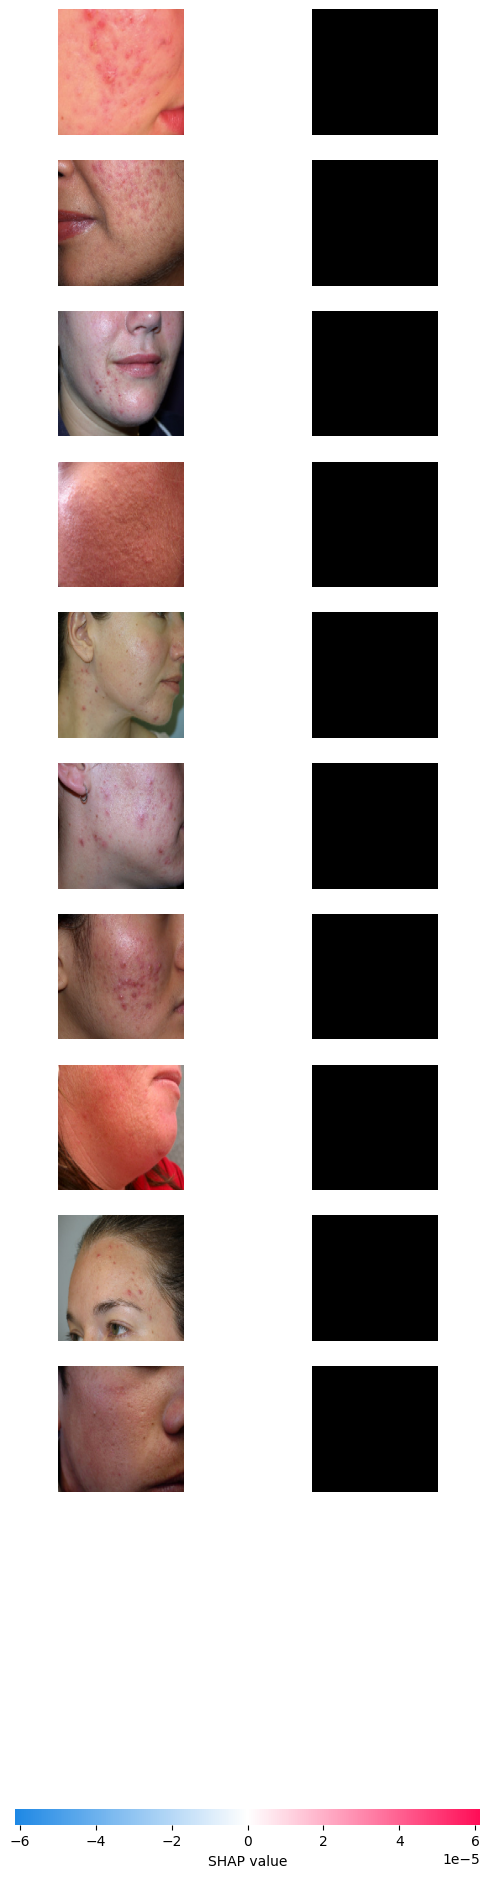

In [6]:
# Select background data for SHAP explanations
sample_batch, _ = next(train_generator)
background = sample_batch[:100]
explainer = shap.DeepExplainer(model, background)

test_images, _ = next(test_generator)
images_to_explain = test_images[:10]
shap_values = explainer.shap_values(images_to_explain)

index = 0  # Change this to visualize different images

plt.figure(figsize=(8, 4))
shap.image_plot(shap_values, images_to_explain)
